# MNIST Regularization (PyTorch)

Dieses Notebook zeigt verschiedene Regularisierungsmethoden auf einem einfachen MLP für MNIST – vollständig in PyTorch und mit expliziten Gewichts-Parametern.

Abgedeckte Kategorien:
- Weiche Regularisierung: L2 (weight_decay), L1 (zusätzlicher Term)
- Harte Regularisierung: Max-Norm, Non-Negativity, Gewichts-Clipping
- Early Stopping
- Regularisierung durch Dropout, optionale BatchNorm
- Output-Regularisierung: Label Smoothing

Voraussetzungen (lokal):
```bash
pip install torch torchvision matplotlib
```


In [9]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu


In [10]:
# Daten laden (MNIST)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_full = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

val_size = 1000
train_size = int(len(train_full)*0.1 - val_size)

indices = torch.randperm(len(train_full), generator=torch.Generator().manual_seed(42))[:(val_size+int(train_size))]
small_ds = Subset(train_full, indices)


train_ds, val_ds = random_split(small_ds, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

len(train_ds), len(val_ds), len(test_ds)


(5000, 1000, 10000)

In [11]:
# Explizite Linearschicht mit nn.Parameter
class ExplicitLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in = self.weight.size(1)
            bound = 1.0 / math.sqrt(fan_in)
            nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x):
        return F.linear(x, self.weight, self.bias)

# Einfaches MLP
class MLP(nn.Module):
    def __init__(self, hidden=64, dropout=0.0, use_bn=False):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = ExplicitLinear(28*28, hidden)
        self.bn1 = nn.BatchNorm1d(hidden) if use_bn else None
        self.dropout = nn.Dropout(p=dropout) if dropout > 0 else None
        self.fc2 = ExplicitLinear(hidden, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        if self.bn1 is not None:
            x = self.bn1(x)
        x = F.relu(x)
        if self.dropout is not None:
            x = self.dropout(x)
        x = self.fc2(x)
        return x

@torch.no_grad()
def apply_constraints(model, cfg):
    for m in model.modules():
        if isinstance(m, ExplicitLinear):
            W = m.weight.data
            # Non-Negativity
            if cfg.get('nonneg', False):
                W.clamp_(min=0.0)
            # Max-Norm pro Zeile (pro Neuron)
            max_norm = cfg.get('max_norm', None)
            if max_norm is not None:
                norms = W.norm(p=2, dim=1, keepdim=True)
                mask = norms > max_norm
                if mask.any():
                    scale = torch.ones_like(norms)
                    scale[mask] = max_norm / norms[mask]
                    W.mul_(scale)
            # Gewichts-Clipping (Elementweise)
            clip_value = cfg.get('clip_value', None)
            if clip_value is not None:
                W.clamp_(-clip_value, clip_value)


In [12]:
def accuracy(logits, y):
    return (logits.argmax(1) == y).float().mean().item()

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(1) == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, total_correct / total

def train_one_model(cfg, epochs=8, patience=3, verbose=False):
    model = MLP(hidden=cfg.get('hidden', 64),
                dropout=cfg.get('dropout', 0.0),
                use_bn=cfg.get('use_bn', False)).to(device)

    label_smoothing = cfg.get('label_smoothing', 0.0)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    wd = cfg.get('l2_weight_decay', 0.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.get('lr', 1e-3), weight_decay=wd)

    l1_lambda = cfg.get('l1_lambda', 0.0)

    best_val = float('inf')
    best_state = None
    wait = 0

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        n = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            if l1_lambda > 0:
                l1 = 0.0
                for m in model.modules():
                    if isinstance(m, ExplicitLinear):
                        l1 = l1 + m.weight.abs().sum()
                loss = loss + l1_lambda * l1
            loss.backward()
            if cfg.get('grad_clip', None) is not None:
                nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
            optimizer.step()
            apply_constraints(model, cfg)
            running_loss += loss.item() * xb.size(0)
            n += xb.size(0)

        train_loss = running_loss / n
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if verbose:
            print(f'Epoch {epoch}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}')

        if cfg.get('use_early_stopping', True):
            if val_loss < best_val - 1e-4:
                best_val = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    if verbose:
                        print('Early stopping')
                    break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_acc = evaluate(model, test_loader, criterion)
    return model, history, {'val_loss': best_val, 'test_acc': test_acc}


In [ ]:
# Beispiel-Experimente definieren
experiments = [
    {'name': 'baseline', 'hidden': 64, 'dropout': 0.0, 'use_bn': False, 'l2_weight_decay': 0.0, 'l1_lambda': 0.0, 'use_early_stopping': True},
    {'name': 'l2', 'l2_weight_decay': 1e-4},
    {'name': 'l1', 'l1_lambda': 1e-6},
    {'name': 'maxnorm', 'max_norm': 3.0},
    {'name': 'nonneg', 'nonneg': True},
    {'name': 'clipW', 'clip_value': 0.5},
    {'name': 'dropout', 'dropout': 0.5},
    {'name': 'label_smooth', 'label_smoothing': 0.1},
]
trained = []  # (name, model, history, stats)

results = []
for cfg in experiments:
    base = {
        'name': cfg.get('name', 'exp'),
        'hidden': cfg.get('hidden', 64),
        'dropout': cfg.get('dropout', 0.0),
        'use_bn': cfg.get('use_bn', False),
        'l2_weight_decay': cfg.get('l2_weight_decay', 0.0),
        'l1_lambda': cfg.get('l1_lambda', 0.0),
        'nonneg': cfg.get('nonneg', False),
        'max_norm': cfg.get('max_norm', None),
        'clip_value': cfg.get('clip_value', None),
        'label_smoothing': cfg.get('label_smoothing', 0.0),
        'use_early_stopping': True,
        'epochs': 8,
        'lr': 1e-3,
    }
    base.update(cfg)
    print(f"Running {base['name']}")
    model, history, stats = train_one_model(base, epochs=base.get('epochs', 8), patience=3, verbose=False)
    results.append((base['name'], history, stats))
    trained.append((base['name'], model, history, stats))

for name, history, stats in results:
    print(f"{name:12s} | best val loss: {stats['val_loss']:.4f} | test acc: {stats['test_acc']:.4f}")


Running baseline


c:\Users\johannes.schwab\AppData\Local\miniconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Running l2
Running l1
Running maxnorm
Running nonneg
Running clipW
Running dropout
Running label_smooth
baseline     | best val loss: 0.3049 | test acc: 0.9237
l2           | best val loss: 0.3225 | test acc: 0.9197
l1           | best val loss: 0.3236 | test acc: 0.9190
maxnorm      | best val loss: 0.3093 | test acc: 0.9212
nonneg       | best val loss: 0.4162 | test acc: 0.8977
clipW        | best val loss: 0.3261 | test acc: 0.9190
dropout      | best val loss: 0.3343 | test acc: 0.9208
label_smooth | best val loss: 0.7700 | test acc: 0.9336


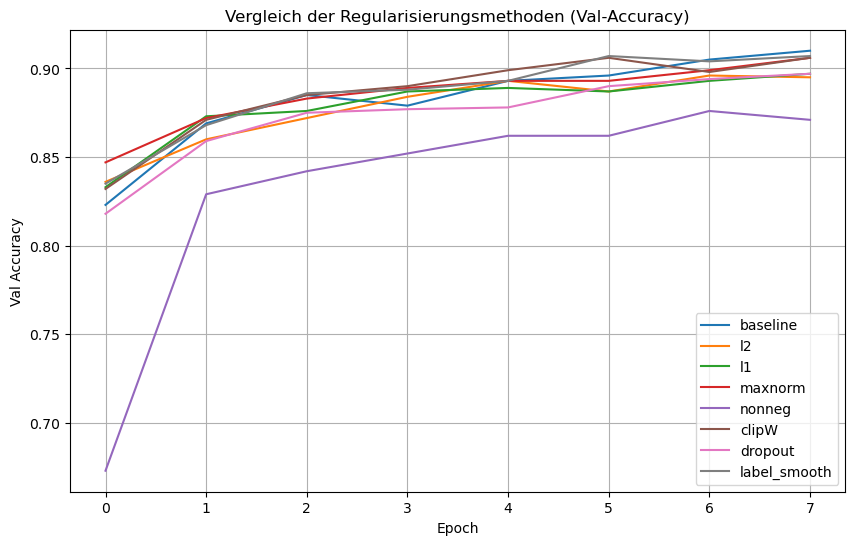

In [14]:

# Visualisierung der Validierungsgenauigkeit
plt.figure(figsize=(10,6))
for name, history, _ in results:
    plt.plot(history['val_acc'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.title('Vergleich der Regularisierungsmethoden (Val-Accuracy)')
plt.legend()
plt.grid(True)
plt.show()


In [15]:
import math

def plot_fc1_filters(model, name, n=16, cmap='coolwarm'):
    W = model.fc1.weight.detach().cpu()
    vmax = float(W.abs().max())
    k = int(math.sqrt(n))
    fig, axes = plt.subplots(k, k, figsize=(2*k, 2*k))
    for i, ax in enumerate(axes.flat[:n]):
        img = W[i].reshape(28, 28)
        im = ax.imshow(img, cmap=cmap, vmin=-vmax, vmax=vmax)
        ax.set_title(f'{i}', fontsize=8)
        ax.axis('off')
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
    plt.suptitle(f'fc1 Gewichte als 28×28 ( {name} )')
    plt.tight_layout()
    plt.show()

def plot_fc2_heatmap(model, name, cmap='coolwarm'):
    W = model.fc2.weight.detach().cpu()  # (10, hidden)
    vmax = float(W.abs().max())
    plt.figure(figsize=(8, 3))
    plt.imshow(W, aspect='auto', cmap=cmap, vmin=-vmax, vmax=vmax)
    plt.colorbar(shrink=0.7)
    plt.yticks(ticks=range(10), labels=[str(i) for i in range(10)])
    plt.xlabel('Hidden-Neuron')
    plt.ylabel('Klasse')
    plt.title(f'fc2 Gewichtsmatrix ( {name} )')
    plt.tight_layout()
    plt.show()

def plot_weight_hist(model, name, layer='fc1'):
    W = getattr(model, layer).weight.detach().cpu().view(-1)
    plt.figure(figsize=(6,3))
    plt.hist(W.numpy(), bins=60, color='steelblue', alpha=0.9)
    plt.title(f'Histogramm {layer}.weight ( {name} )')
    plt.xlabel('Gewicht')
    plt.ylabel('Häufigkeit')
    plt.tight_layout()
    plt.show()

def weight_stats(model):
    stats = {}
    for lname in ['fc1', 'fc2']:
        W = getattr(model, lname).weight.detach().cpu()
        stats[lname] = {
            'L1_norm': float(W.abs().sum()),
            'L2_norm': float(W.pow(2).sum().sqrt()),
            'max_abs': float(W.abs().max()),
            'sparsity_frac(|w|<1e-3)': float((W.abs() < 1e-3).float().mean())
        }
    return stats


C:\Users\johannes.schwab\AppData\Local\Temp\ipykernel_33084\1825896746.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


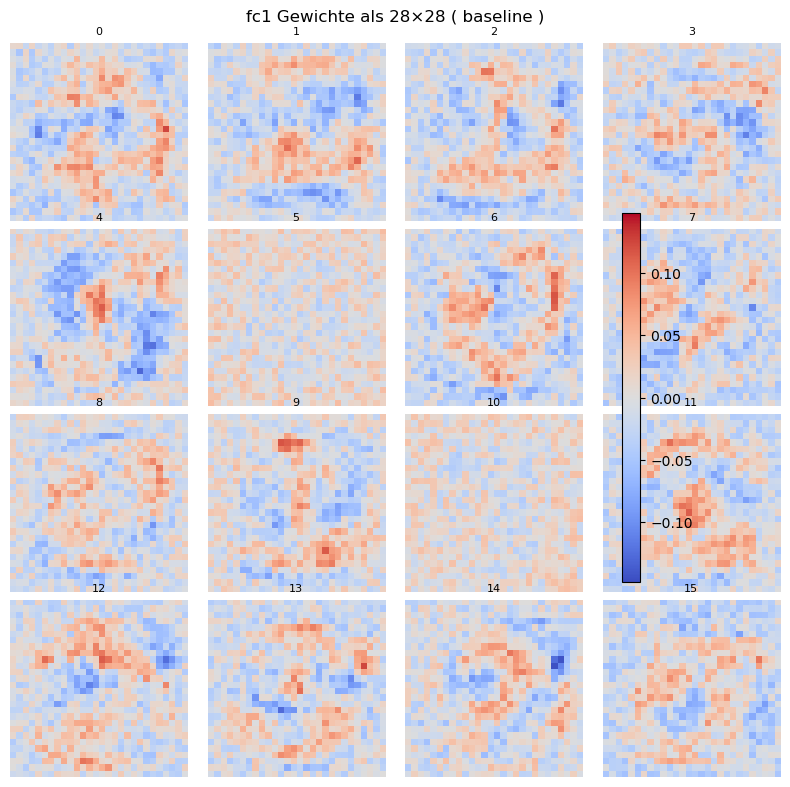

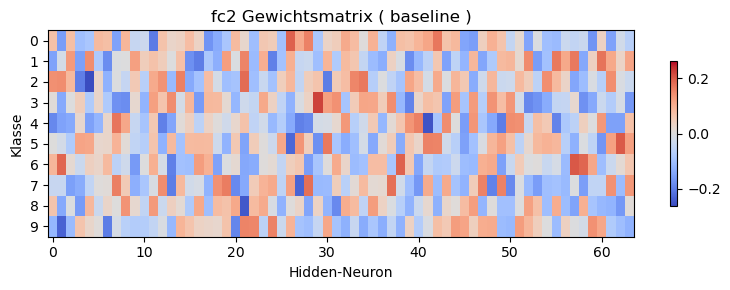

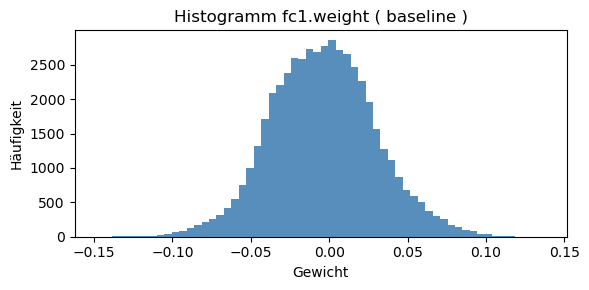

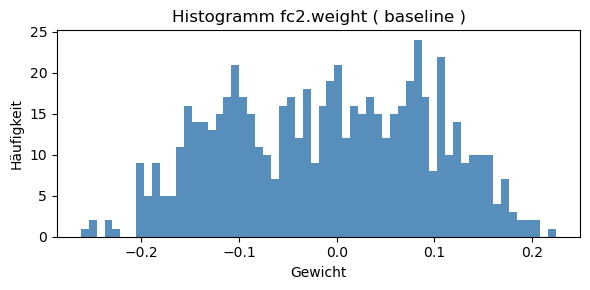

baseline {'fc1': {'L1_norm': 1341.0262451171875, 'L2_norm': 7.530453681945801, 'max_abs': 0.14802630245685577, 'sparsity_frac(|w|<1e-3)': 0.023218272253870964}, 'fc2': {'L1_norm': 56.51018524169922, 'L2_norm': 2.633147716522217, 'max_abs': 0.26190030574798584, 'sparsity_frac(|w|<1e-3)': 0.00937500037252903}}


C:\Users\johannes.schwab\AppData\Local\Temp\ipykernel_33084\1825896746.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


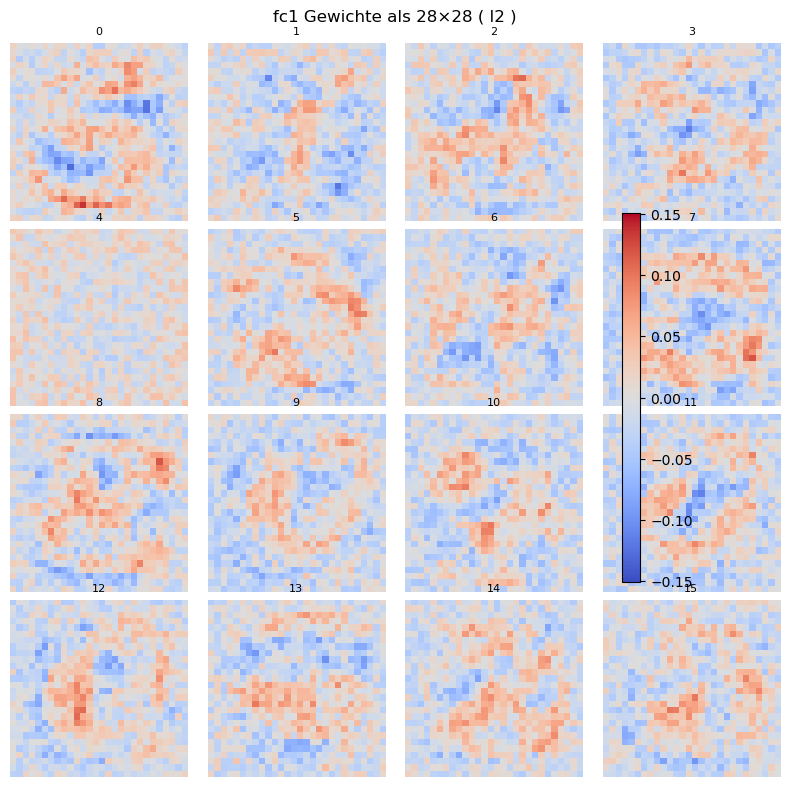

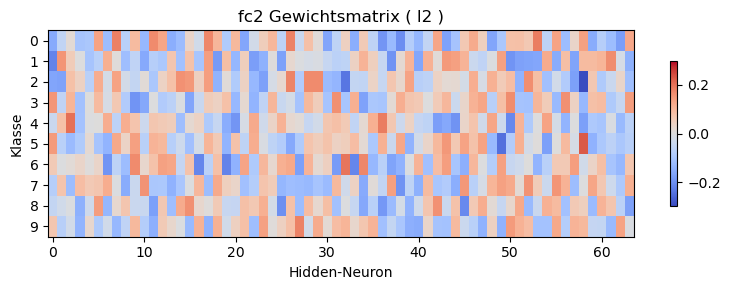

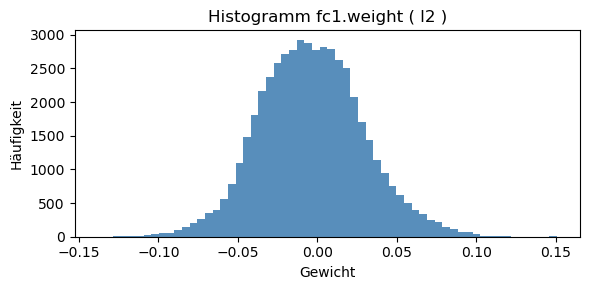

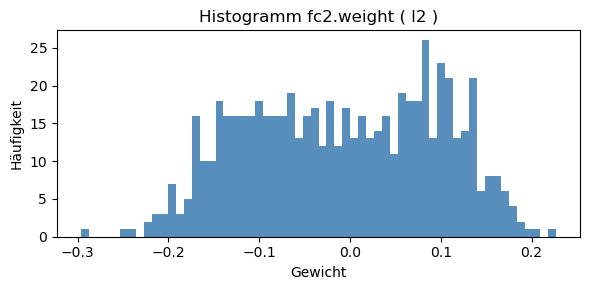

l2 {'fc1': {'L1_norm': 1313.9285888671875, 'L2_norm': 7.375695705413818, 'max_abs': 0.15088318288326263, 'sparsity_frac(|w|<1e-3)': 0.02220184914767742}, 'fc2': {'L1_norm': 57.66301727294922, 'L2_norm': 2.6443967819213867, 'max_abs': 0.29642561078071594, 'sparsity_frac(|w|<1e-3)': 0.0062500000931322575}}


C:\Users\johannes.schwab\AppData\Local\Temp\ipykernel_33084\1825896746.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


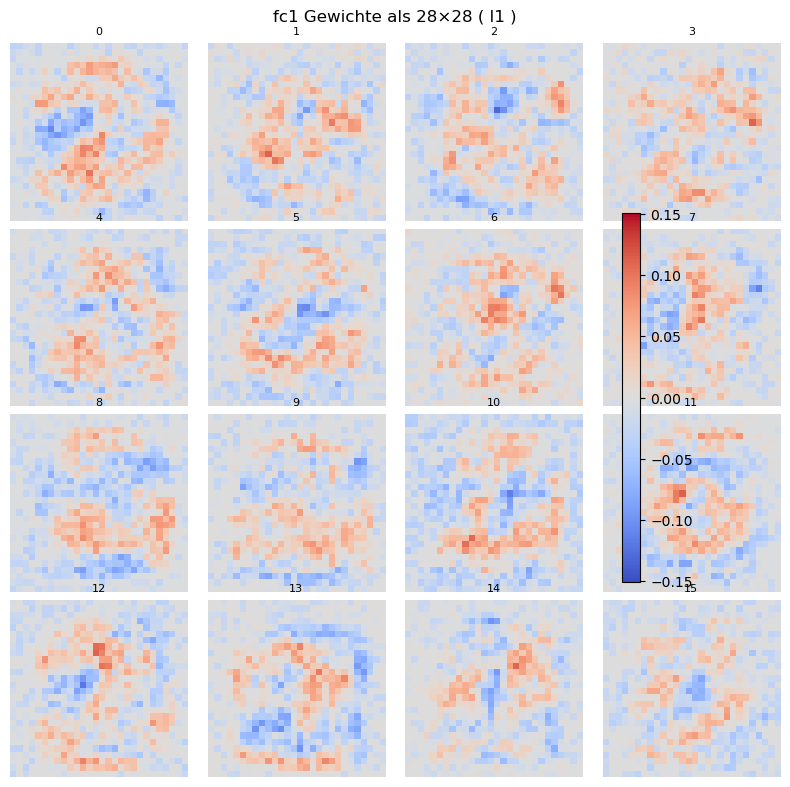

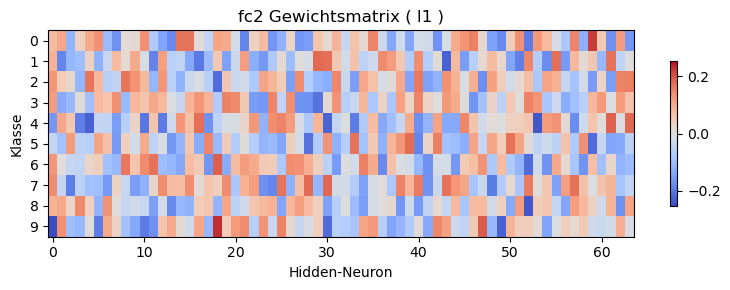

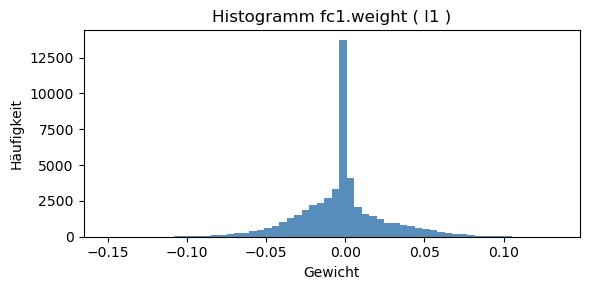

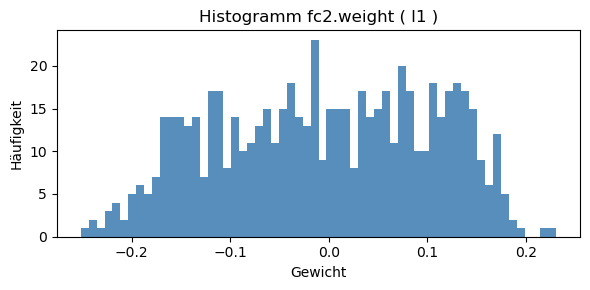

l1 {'fc1': {'L1_norm': 914.269775390625, 'L2_norm': 6.0613579750061035, 'max_abs': 0.15102536976337433, 'sparsity_frac(|w|<1e-3)': 0.15621013939380646}, 'fc2': {'L1_norm': 58.99837875366211, 'L2_norm': 2.7314374446868896, 'max_abs': 0.25148844718933105, 'sparsity_frac(|w|<1e-3)': 0.00937500037252903}}


C:\Users\johannes.schwab\AppData\Local\Temp\ipykernel_33084\1825896746.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


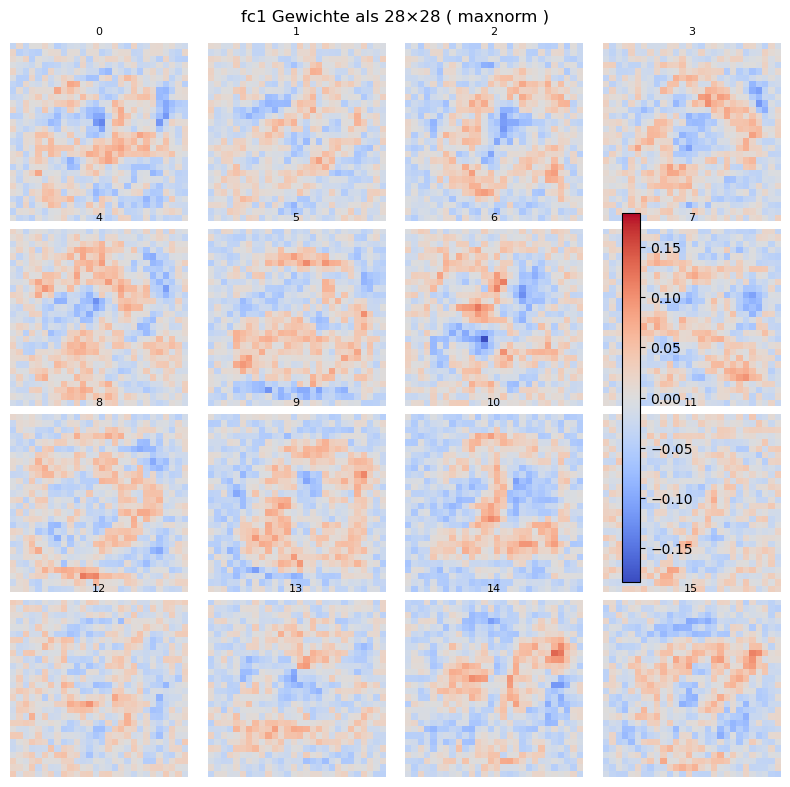

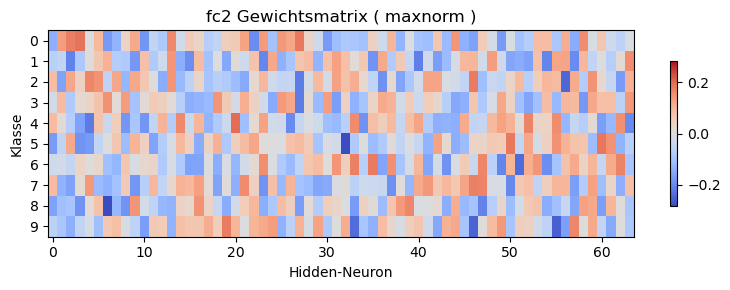

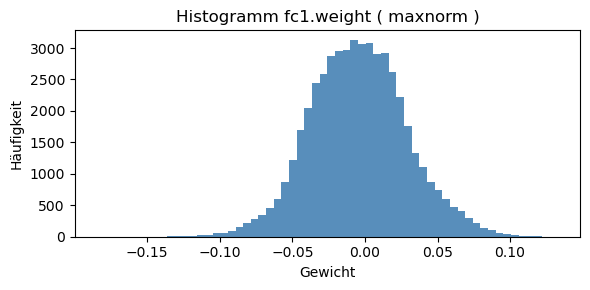

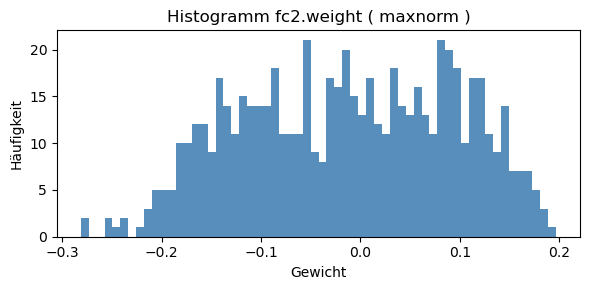

maxnorm {'fc1': {'L1_norm': 1340.772216796875, 'L2_norm': 7.533012866973877, 'max_abs': 0.1841410994529724, 'sparsity_frac(|w|<1e-3)': 0.023557079955935478}, 'fc2': {'L1_norm': 58.039161682128906, 'L2_norm': 2.703618288040161, 'max_abs': 0.2813127040863037, 'sparsity_frac(|w|<1e-3)': 0.0078125}}


C:\Users\johannes.schwab\AppData\Local\Temp\ipykernel_33084\1825896746.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


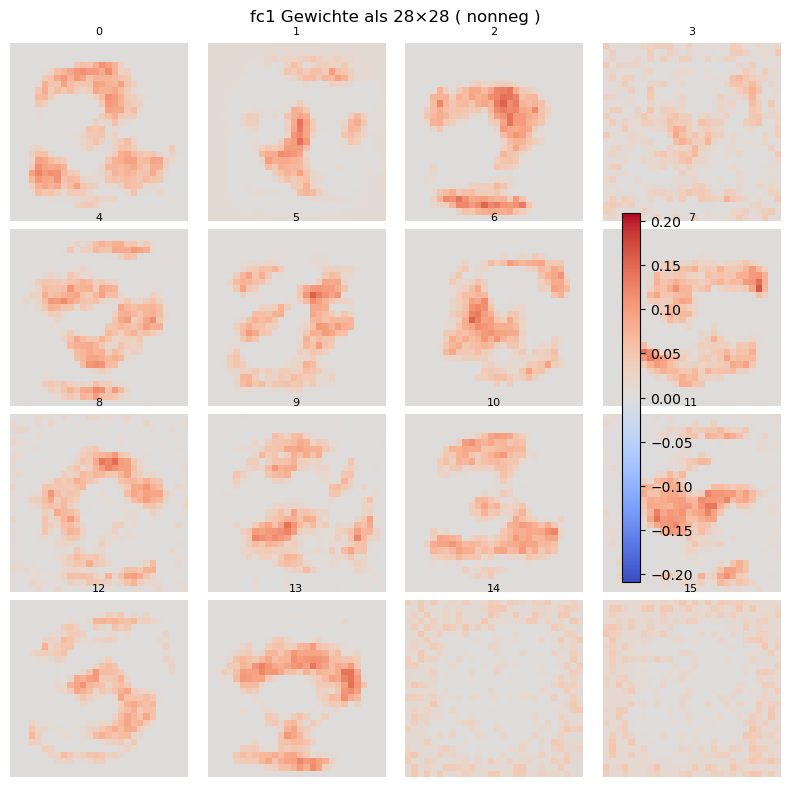

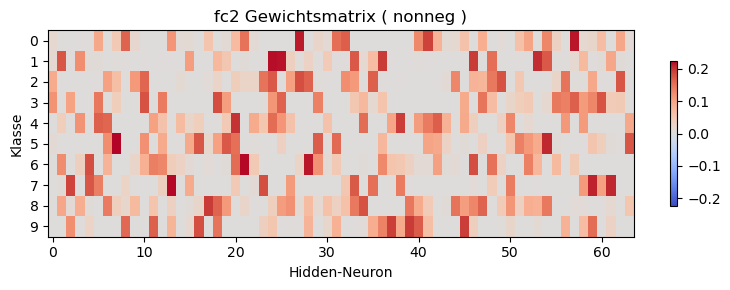

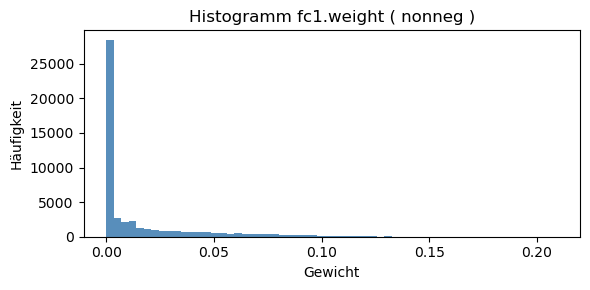

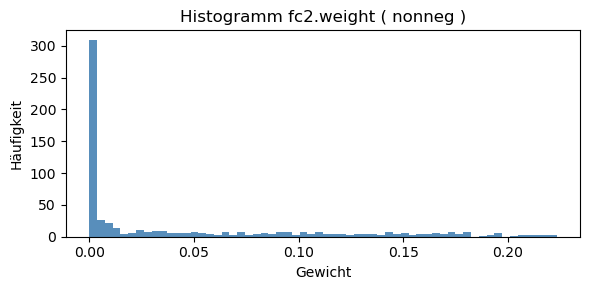

nonneg {'fc1': {'L1_norm': 800.898681640625, 'L2_norm': 6.959267616271973, 'max_abs': 0.20943224430084229, 'sparsity_frac(|w|<1e-3)': 0.4773995578289032}, 'fc2': {'L1_norm': 28.653776168823242, 'L2_norm': 1.9463231563568115, 'max_abs': 0.22322845458984375, 'sparsity_frac(|w|<1e-3)': 0.3687500059604645}}


C:\Users\johannes.schwab\AppData\Local\Temp\ipykernel_33084\1825896746.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


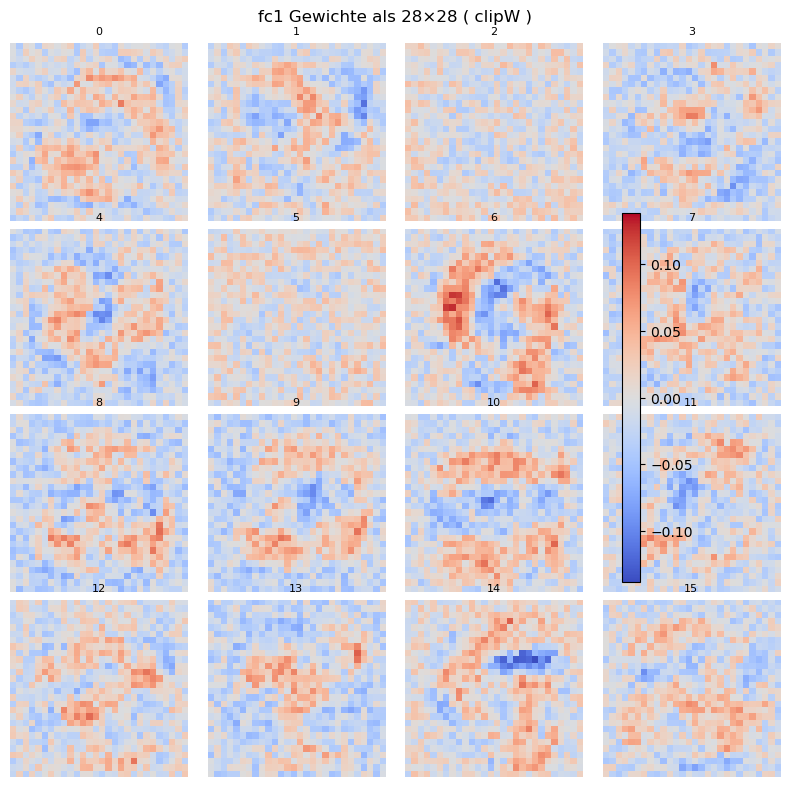

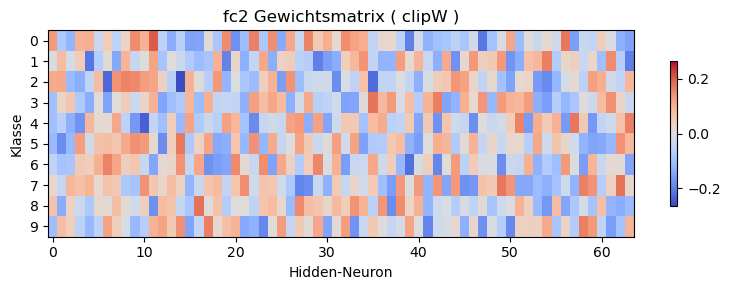

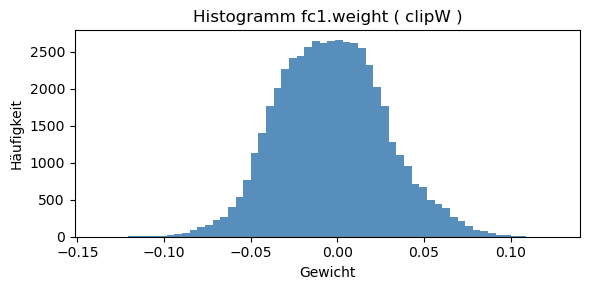

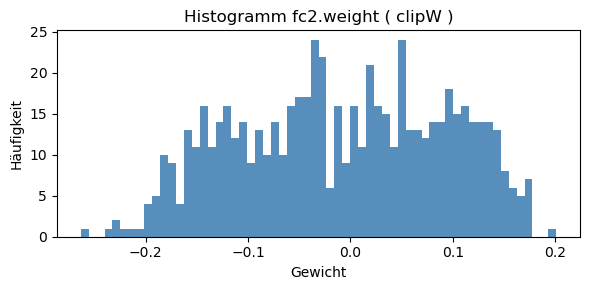

clipW {'fc1': {'L1_norm': 1260.4765625, 'L2_norm': 6.998196601867676, 'max_abs': 0.13827179372310638, 'sparsity_frac(|w|<1e-3)': 0.024752870202064514}, 'fc2': {'L1_norm': 55.088443756103516, 'L2_norm': 2.558769464492798, 'max_abs': 0.2635837495326996, 'sparsity_frac(|w|<1e-3)': 0.0031250000465661287}}


C:\Users\johannes.schwab\AppData\Local\Temp\ipykernel_33084\1825896746.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


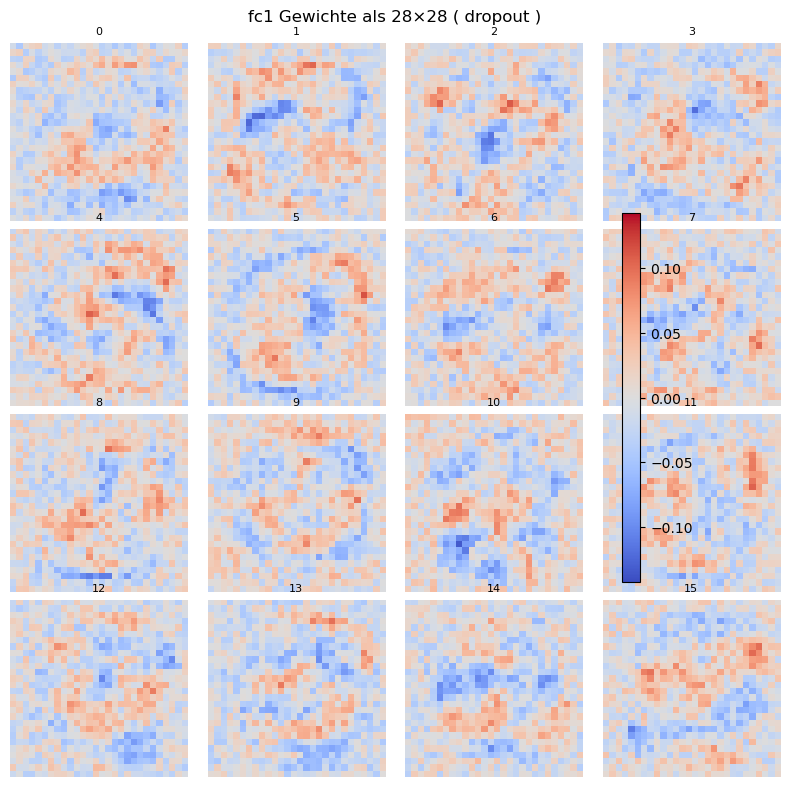

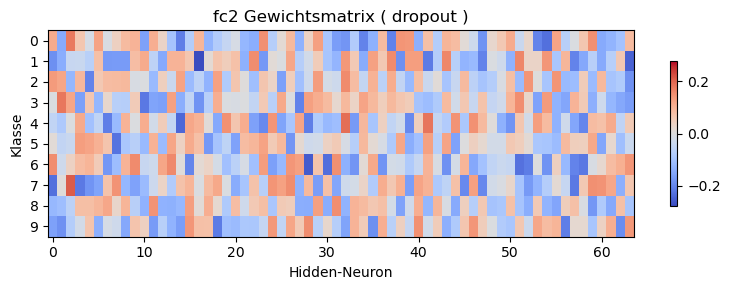

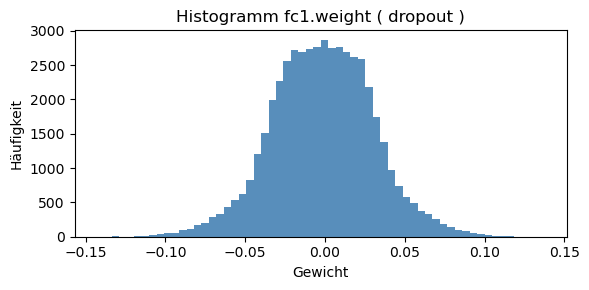

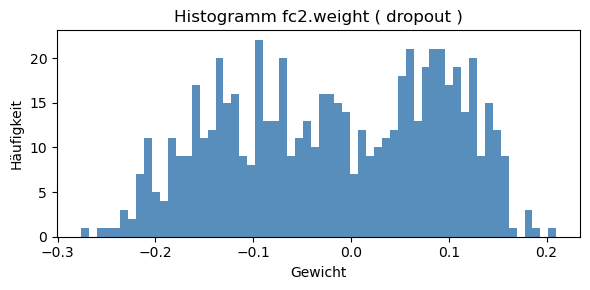

dropout {'fc1': {'L1_norm': 1264.84130859375, 'L2_norm': 7.111522197723389, 'max_abs': 0.1428055614233017, 'sparsity_frac(|w|<1e-3)': 0.024055324494838715}, 'fc2': {'L1_norm': 61.224857330322266, 'L2_norm': 2.796551465988159, 'max_abs': 0.27633193135261536, 'sparsity_frac(|w|<1e-3)': 0.0015625000232830644}}


C:\Users\johannes.schwab\AppData\Local\Temp\ipykernel_33084\1825896746.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


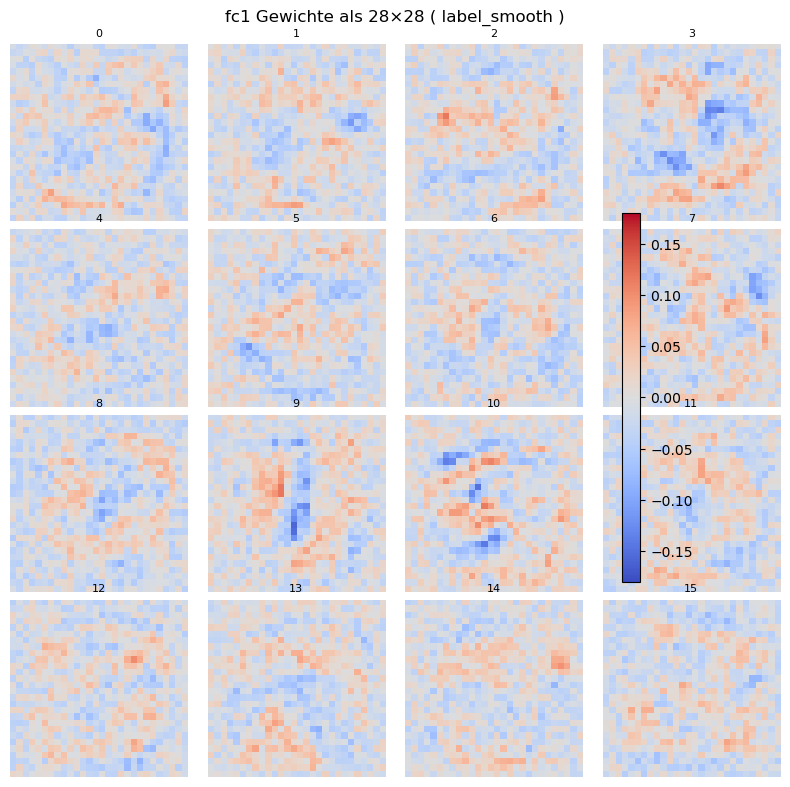

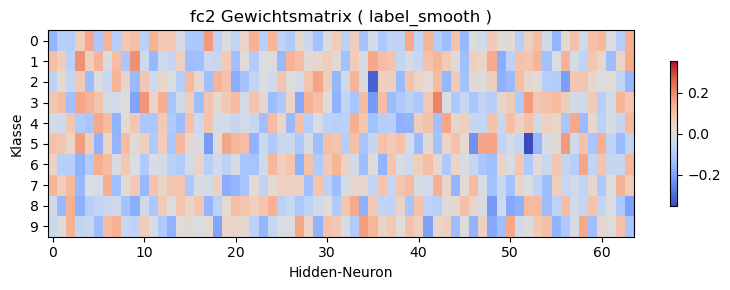

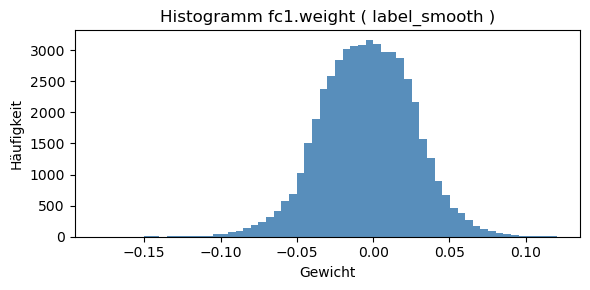

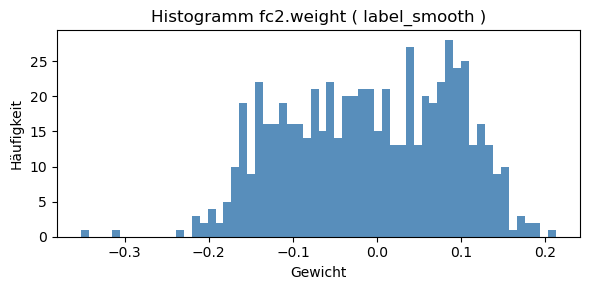

label_smooth {'fc1': {'L1_norm': 1221.67724609375, 'L2_norm': 6.85984992980957, 'max_abs': 0.18050359189510345, 'sparsity_frac(|w|<1e-3)': 0.02495216764509678}, 'fc2': {'L1_norm': 53.5035400390625, 'L2_norm': 2.4894766807556152, 'max_abs': 0.35235923528671265, 'sparsity_frac(|w|<1e-3)': 0.0062500000931322575}}


In [16]:
# Liste der zu vergleichenden Varianten, z. B. alle oder eine Auswahl
names_to_plot = [name for name, *_ in trained]

for name, model, history, stats in trained:
    if name in names_to_plot:
        plot_fc1_filters(model, name, n=16)     # 
        plot_fc2_heatmap(model, name)           # Heatmap der zweiten Schicht
        plot_weight_hist(model, name, layer='fc1')
        plot_weight_hist(model, name, layer='fc2')
        print(name, weight_stats(model))

## Hinweise
- Du kannst die Experimente oben anpassen oder einzelne Konfigurationen auskommentieren.
- Die harten Constraints (nonneg, max_norm, clip) werden nach jedem Optimizer-Step projiziert.
- L1 wird als zusätzlicher Verlustterm nur auf Gewichte der expliziten Linearschichten angewandt.
- Early Stopping ist standardmäßig aktiv (patience=3).
